In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path
sys.path.append('/lab/barcheese01/smaffa/coTISja/src')

from scripts.filter_utils import *
import re

In [116]:
# from raw sample-level data
sample_level_tis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/combined/all_samples_filtered_with_protein_seq.csv')
sample_level_tis_df = calculate_normalization_factors(sample_level_tis_df, pseudocount=1)

# grab normalization factors
experiment_table, sample_df, replicate_df = load_experiment_manifest()
tisdiff_manifest = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/ribotish_tisdiff_manifest.tsv', sep='\t')
samples = experiment_table['sample'].tolist()
codon_order = ['ATG', 'ATA', 'ATC', 'ATT', 'ACG', 'AAG', 'AGG', 'GTG', 'TTG', 'CTG']
sample_to_riboseq_total = replicate_df[replicate_df['condition'] == 'TIS'].groupby('sample')['bam_qc_file'].apply(list).apply(lambda x: np.sum([calculate_read_totals_from_bam_qc(y) for y in x]))
sample_to_riboseq_scale_factor = (sample_to_riboseq_total.median() / sample_to_riboseq_total).rename('SampleRPFScaleFactor')
sample_level_tis_df = sample_level_tis_df.merge(sample_to_riboseq_scale_factor, left_on='Sample', right_index=True)

sample_level_tis_df = sample_level_tis_df.assign(
    TIS=sample_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log

<Axes: xlabel='LogTranslationEfficiency', ylabel='Density'>

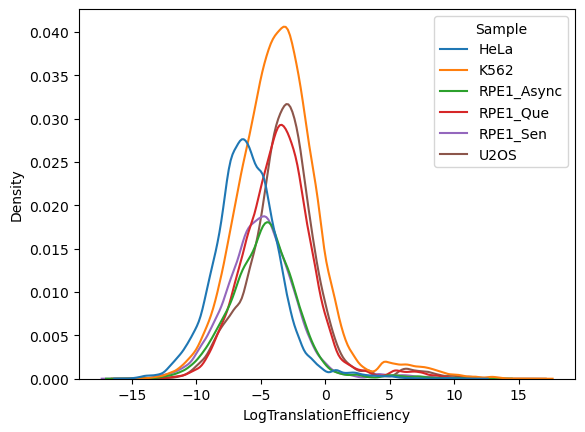

In [4]:
# calculate TE values
sample_level_tis_df = sample_level_tis_df.assign(
    LogTranslationEfficiency = lambda x: np.log2(x['SampleRPFScaleFactor'] * (x['TISCounts'] + 1)) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    # LogTranslationEfficiency = lambda x: np.log2(x['TISCounts'] + 1) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    TranslationEfficiency = lambda x: 2**x['LogTranslationEfficiency']
)
sample_level_tis_df = sample_level_tis_df.assign(
    TIS=sample_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)

sns.kdeplot(
    sample_level_tis_df,
    x='LogTranslationEfficiency', hue='Sample'
)

<Axes: xlabel='LogTranslationEfficiency', ylabel='Density'>

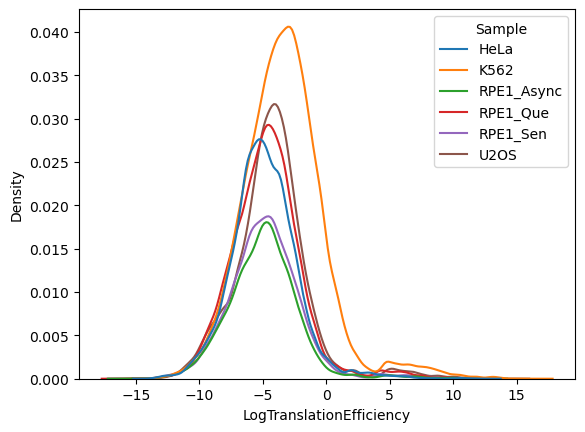

In [6]:
# calculate TE values
sample_level_tis_df = sample_level_tis_df.assign(
    # LogTranslationEfficiency = lambda x: np.log2(x['SampleRPFScaleFactor'] * (x['TISCounts'] + 1)) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    LogTranslationEfficiency = lambda x: np.log2(x['TISCounts'] + 1) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    TranslationEfficiency = lambda x: 2**x['LogTranslationEfficiency']
)
sample_level_tis_df = sample_level_tis_df.assign(
    TIS=sample_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)

sns.kdeplot(
    sample_level_tis_df,
    x='LogTranslationEfficiency', hue='Sample'
)

In [5]:
# from DESeq2 transformation
translation_efficiency_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/translation_efficiency_vst_matrix.csv', index_col=0)
masked_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/log_translation_efficiency_coeffs_masked.csv', index_col=0)

<Axes: xlabel='value', ylabel='Density'>

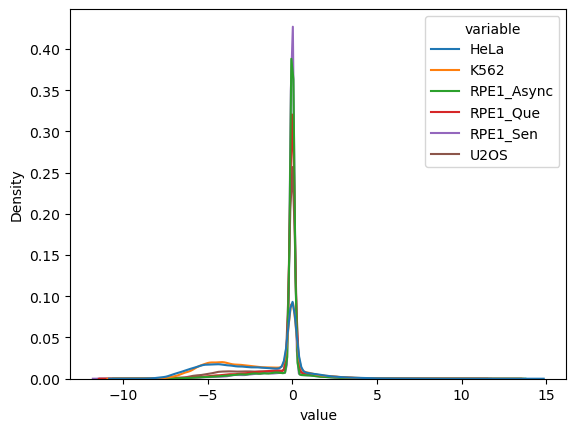

In [8]:
sns.kdeplot(
    translation_efficiency_matrix.melt(),
    x='value', hue='variable'
)

<Axes: xlabel='value', ylabel='Density'>

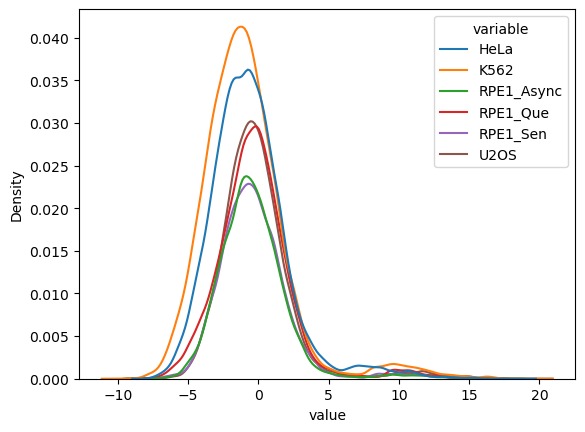

In [9]:
sns.kdeplot(
    masked_log_te_matrix.melt(),
    x='value', hue='variable'
)

<Axes: xlabel='value', ylabel='Density'>

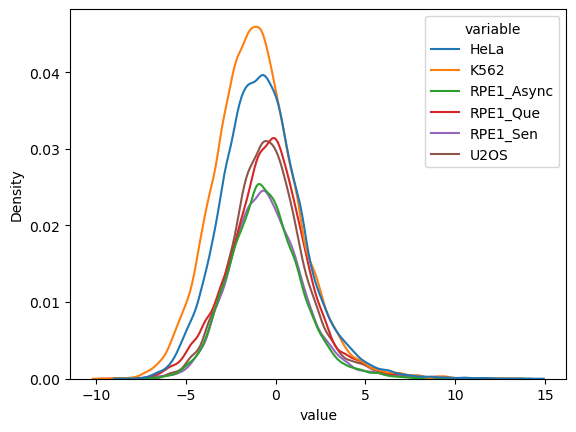

In [10]:
sns.kdeplot(
    translation_efficiency_matrix[~masked_log_te_matrix.isna()].melt(),
    x='value', hue='variable'
)

In [6]:
masked_te_matrix = translation_efficiency_matrix[~masked_log_te_matrix.isna()]

In [105]:
# sample_level_translation_efficiency = sample_level_tis_df.pivot_table(index='TIS', columns='Sample', values='TranslationEfficiency')
sample_level_riboseq_counts = sample_level_tis_df.pivot_table(index='TIS', columns='Sample', values='TISCounts')

In [117]:
tis_metadata = sample_level_tis_df[['TIS', 'IsoformID', 'Tid', 'Symbol', 'Gid', 'GeneType', 'StartCodon', 'Start', 'RecatTISType', 'MANE_Select', 'AALen', 'AASeq']].drop_duplicates()

# Summarizing differential TIS metrics

1) Need to find a way to summarize per TIS, or make a function to extract when queried, the matrix of differential comparisons between samples
    - Done: exported stacked matrices per TIS over all pairs of samples
2) Want to find a way to summarize per TIS, the "outlier-ness" of translation efficiency values in any cell line, along with a statistical measure of this quantity - maybe these are worth experimentally testing
    - Ranking heuristic is ok: reporting the variance, maximum, and minimum of TE values, along with the most significant and median differential qvalue per TIS. Outliers should have high variance and a most significant q-value which is far from the median q-value. Conversely, non-outliers but differential across samples should have high variance, and a significant median q-value (i.e. more than half of pairwise comparisons should have significant differences in translation efficiency)
3) Want to report some statistical measure per TIS, of "interesting-ness" / "different-ness" across cell lines
    - TODO: some rank which combines these?
    - TODO: ranks for each (outlier-ness, vs. differential across all pairs)?
3) Need to make some gene-level comparisons with RNA expression or protein expression or essentiality across cell lines
    - TODO: use the highest ranking "differential across all pairs" or highest variance TISs as a subset of genes to run correlations with other measurements?
    - TODO: GO enrichment analysis on the genes with the most differential TISs?

In [8]:
import os
import re

pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/pairwise_wald/{f}', index_col=0)

In [9]:
# function to pull out statistics for a TIS across all pairwise comparisons
def extract_TIS_matrix(TIS, pairwise_dict=pairwise_wald_tests, comparison_metric='log2FoldChange', masked_tis_matrix=masked_te_matrix):
    single_samples = set()
    for s1, s2 in pairwise_dict:
        single_samples.add(s1)
        single_samples.add(s2)
    single_samples = sorted(list(single_samples))
    n_samples = len(single_samples)

    output_matrix = np.empty(shape=(n_samples, n_samples))
    output_matrix.fill(np.nan)
    output_matrix = pd.DataFrame(output_matrix, index=single_samples, columns=single_samples)

    for pair, df in pairwise_dict.items():
        s1, s2 = pair
        if TIS in df.index.tolist():
            output_matrix.loc[s1, s2] = df.loc[TIS, comparison_metric]
        if masked_tis_matrix is not None:
            if TIS in masked_tis_matrix.index.tolist() and s1 in masked_tis_matrix.columns.tolist() and s2 in masked_tis_matrix.columns.tolist():
                if np.isnan(masked_tis_matrix.loc[TIS, s1]) and np.isnan(masked_tis_matrix.loc[TIS, s2]):
                    output_matrix.loc[s1, s2] = np.nan

    return output_matrix

In [52]:
def extract_TIS_block(comparison_metric='log2FoldChange', pairwise_dict=pairwise_wald_tests, masked_tis_matrix=masked_te_matrix):
    single_samples = set()
    tis_superindex = set()
    for s1, s2 in pairwise_dict:
        single_samples.add(s1)
        single_samples.add(s2)
        tis_superindex = tis_superindex.union(pairwise_dict[(s1, s2)].index.tolist())
    single_samples = sorted(list(single_samples))
    tis_superindex = sorted(list(tis_superindex))
    n_samples = len(single_samples)
    n_tis = len(tis_superindex)

    sample_index = pd.Series(range(n_samples), index=single_samples)
    tis_index = pd.Series(range(n_tis), index=tis_superindex)

    output_matrix = np.empty(shape=(n_tis, n_samples, n_samples))
    output_matrix.fill(np.nan)

    for pair, df in tqdm(pairwise_dict.items()):
        s1, s2 = pair
        output_matrix[:, sample_index.loc[s1], sample_index.loc[s2]] = df.reindex(index=tis_superindex)[comparison_metric].values

        if masked_tis_matrix is not None:
            na_mask = masked_tis_matrix.reindex(index=tis_superindex)[[s1, s2]].isna().all(axis=1).tolist()
            output_matrix[na_mask, sample_index.loc[s1], sample_index.loc[s2]] = np.nan

    output_block = pd.DataFrame(
        output_matrix.reshape(tis_index.shape[0] * sample_index.shape[0], sample_index.shape[0]),
        index=pd.MultiIndex.from_product([tis_index.index.tolist(), sample_index.index.tolist()], names=['TIS', 'TestSample']),
        columns=sample_index.index.tolist()
    )
    output_block.columns.name='RefSample'
    return output_block

In [53]:
lfc_block = extract_TIS_block(comparison_metric='log2FoldChange')
pval_block = extract_TIS_block(comparison_metric='pvalue')
qval_block = extract_TIS_block(comparison_metric='padj')

100%|██████████| 15/15 [00:02<00:00,  5.47it/s]


In [162]:
lfc_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/lfc_matrix_stack.csv')
pval_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/pval_matrix_stack.csv')
qval_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/qval_matrix_stack.csv')

In [31]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+', masked_tis_matrix=None)

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
HeLa,NaN,NaN,NaN,NaN,NaN,NaN
K562,-2.320435,NaN,NaN,NaN,NaN,NaN
RPE1_Async,-2.305267,0.015168,NaN,NaN,NaN,NaN
RPE1_Que,-2.827418,-0.506983,-0.522151,NaN,NaN,NaN
RPE1_Sen,-2.225019,0.095415,0.080248,0.602398,NaN,NaN
U2OS,-0.783553,1.536882,1.521714,2.043865,1.441467,NaN


In [ ]:
lfc.loc[pd.IndexSlice[:, 'U2OS'], 'HeLa']

TIS                                     TestSample
ENST00000598814.1_60_chr19:18573300:+   U2OS         -12.221196
ENST00000442744.7_61_chr19:18573300:+   U2OS         -12.221196
ENST00000314332.5_39_chr6:26123871:-    U2OS         -11.323188
ENST00000396984.2_55_chr6:26123871:-    U2OS         -11.323188
ENST00000318911.5_108_chr8:144095183:+  U2OS         -11.214907
                                                        ...    
ENST00000713560.1_63_chr10:75109094:-   U2OS                NaN
ENST00000713907.1_639_chr19:7917559:+   U2OS                NaN
ENST00000715679.1_49_chr5:140565890:+   U2OS                NaN
ENST00000715679.1_67_chr5:140565908:+   U2OS                NaN
ENST00000718285.1_79_chr20:58850823:-   U2OS                NaN
Name: HeLa, Length: 169838, dtype: float64

In [ ]:
pd.DataFrame(lfc_block, index=)

In [32]:
lfc_block[tis_index.loc['ENST00000624697.4_245_chr1:1013998:+'], :, :]

array([[        nan,         nan,         nan,         nan,         nan,
                nan],
       [-2.32043492,         nan,         nan,         nan,         nan,
                nan],
       [-2.30526694,  0.01516798,         nan,         nan,         nan,
                nan],
       [-2.82741777, -0.50698284,         nan,         nan,         nan,
                nan],
       [-2.22501943,  0.0954155 ,         nan,         nan,         nan,
                nan],
       [-0.78355257,  1.53688235,  1.52171437,  2.0438652 ,  1.44146686,
                nan]])

In [ ]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+', masked_tis_matrix=None, comparison_metric='padj')

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
HeLa,NaN,NaN,NaN,NaN,NaN,NaN
K562,0.006688,NaN,NaN,NaN,NaN,NaN
RPE1_Async,0.276164,1.000000,NaN,NaN,NaN,NaN
RPE1_Que,0.165688,0.940888,1.0,NaN,NaN,NaN
RPE1_Sen,0.130065,1.000000,1.0,1.000000,NaN,NaN
U2OS,0.454491,0.244651,1.0,0.882203,1.0,NaN


In [ ]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+')

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS
HeLa,NaN,NaN,NaN,NaN,NaN,NaN
K562,-2.320435,NaN,NaN,NaN,NaN,NaN
RPE1_Async,-2.305267,0.015168,NaN,NaN,NaN,NaN
RPE1_Que,-2.827418,-0.506983,NaN,NaN,NaN,NaN
RPE1_Sen,-2.225019,0.095415,NaN,NaN,NaN,NaN
U2OS,-0.783553,1.536882,1.521714,2.043865,1.441467,NaN


In [60]:
pairwise_wald_tests[('K562', 'HeLa')]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ENST00000327044.7_16_chr1:959240:-,253.142588,1.677598,0.445448,3.766093,1.658223e-04,1.635216e-03
ENST00000487214.1_90_chr1:959219:-,163.792301,-2.971545,0.376294,-7.896875,2.859839e-15,2.151207e-13
ENST00000624697.4_245_chr1:1013998:+,17.930677,-2.320435,0.694936,-3.339061,8.406204e-04,6.687940e-03
ENST00000649529.1_50_chr1:1013546:+,24.568539,-6.253917,1.119722,-5.585243,2.333742e-08,5.815041e-07
ENST00000360001.12_263_chr1:1228793:-,221.568949,-5.208643,0.773082,-6.737501,1.611340e-11,7.030520e-10
...,...,...,...,...,...,...
ENST00000369479.1_511_chrX:155061980:-,2.546545,1.697458,10.400257,0.163213,8.703507e-01,NaN
ENST00000369462.5_37_chrX:155071539:+,4.929710,1.697529,10.400257,0.163220,8.703453e-01,NaN
ENST00000330045.12_32_chrX:155071539:+,4.929710,1.697529,10.400257,0.163220,8.703453e-01,NaN
ENST00000369505.5_620_chrX:155382714:+,2.169470,1.696620,10.400257,0.163132,8.704141e-01,NaN


In [30]:
pairwise_wald_tests[('RPE1_Async', 'HeLa')]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ENST00000327044.7_16_chr1:959240:-,253.142588,1.442438,0.474938,3.037105,0.002389,0.008513
ENST00000487214.1_90_chr1:959219:-,163.792301,-1.041546,0.433856,-2.400671,0.016365,0.047792
ENST00000624697.4_245_chr1:1013998:+,17.930677,-2.305267,1.465988,-1.572501,0.115834,0.276164
ENST00000649529.1_50_chr1:1013546:+,24.568539,-4.231402,1.462670,-2.892931,0.003817,0.012981
ENST00000360001.12_263_chr1:1228793:-,221.568949,-6.713891,1.469432,-4.569037,0.000005,0.000032
...,...,...,...,...,...,...
ENST00000369479.1_511_chrX:155061980:-,2.546545,2.522945,10.400257,0.242585,0.808327,NaN
ENST00000369462.5_37_chrX:155071539:+,4.929710,2.523016,10.400257,0.242592,0.808322,NaN
ENST00000330045.12_32_chrX:155071539:+,4.929710,2.523016,10.400257,0.242592,0.808322,NaN
ENST00000369505.5_620_chrX:155382714:+,2.169470,2.522107,10.400257,0.242504,0.808389,NaN


In [31]:
pairwise_wald_tests[('U2OS', 'K562')]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ENST00000327044.7_16_chr1:959240:-,253.142588,-0.458233,0.446491,-1.026297,0.304751,0.563802
ENST00000487214.1_90_chr1:959219:-,163.792301,1.841663,0.466488,3.947934,0.000079,0.000480
ENST00000624697.4_245_chr1:1013998:+,17.930677,1.536882,0.857641,1.791987,0.073135,0.244651
ENST00000649529.1_50_chr1:1013546:+,24.568539,-0.476887,1.816436,-0.262540,0.792905,0.982513
ENST00000360001.12_263_chr1:1228793:-,221.568949,-0.390602,1.627967,-0.239932,0.810383,0.999570
...,...,...,...,...,...,...
ENST00000369479.1_511_chrX:155061980:-,2.546545,-4.394894,10.224789,-0.429827,0.667321,NaN
ENST00000369462.5_37_chrX:155071539:+,4.929710,-5.100580,10.217450,-0.499203,0.617636,NaN
ENST00000330045.12_32_chrX:155071539:+,4.929710,-5.100580,10.217450,-0.499203,0.617636,NaN
ENST00000369505.5_620_chrX:155382714:+,2.169470,6.250963,10.314382,0.606043,0.544486,NaN


In [68]:
masked_te_matrix.merge(tis_metadata, left_index=True, right_on='TIS')

,HeLa,K562,RPE1_Async,RPE1_Que,RPE1_Sen,U2OS,TIS,IsoformID,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select
0,-1.679100,0.070726,-0.143850,0.094285,0.469473,-0.545137,ENST00000327044.7_16_chr1:959240:-,ENST00000327044.7:16,ENST00000327044.7,NOC2L,ENSG00000188976.12,protein_coding,ATG,16.0,Annotated,True
1,-0.585882,-3.504089,-1.857308,NaN,-2.346172,-1.763026,ENST00000487214.1_90_chr1:959219:-,ENST00000487214.1:90,ENST00000487214.1,NOC2L,ENSG00000188976.12,protein_coding,AAG,90.0,Other,False
3,0.084158,-1.735809,NaN,NaN,NaN,-0.657603,ENST00000624697.4_245_chr1:1013998:+,ENST00000624697.4:245,ENST00000624697.4,ISG15,ENSG00000187608.11,protein_coding,GTG,245.0,Extended,False
5,1.847290,NaN,NaN,NaN,NaN,NaN,ENST00000649529.1_50_chr1:1013546:+,ENST00000649529.1:50,ENST00000649529.1,ISG15,ENSG00000187608.11,protein_coding,GTG,50.0,Extended,True
19,-1.530954,NaN,NaN,NaN,NaN,NaN,ENST00000360001.12_263_chr1:1228793:-,ENST00000360001.12:263,ENST00000360001.12,SDF4,ENSG00000078808.21,protein_coding,ATG,263.0,Extended,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243257,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000361981.7_2862_chrX:153865190:-,ENST00000361981.7:2862,ENST00000361981.7,L1CAM,ENSG00000198910.15,protein_coding,TTG,2862.0,Truncated,False
243259,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000370060.7_2986_chrX:153865190:-,ENST00000370060.7:2986,ENST00000370060.7,L1CAM,ENSG00000198910.15,protein_coding,TTG,2986.0,Truncated,True
243365,NaN,NaN,NaN,NaN,NaN,-1.989196,ENST00000475423.1_132_chrX:154764900:+,ENST00000475423.1:132,ENST00000475423.1,DKC1,ENSG00000130826.20,protein_coding,ATT,132.0,Other,False
102973,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000369479.1_511_chrX:155061980:-,ENST00000369479.1:511,ENST00000369479.1,CMC4,ENSG00000182712.16,protein_coding,ATG,511.0,Truncated,False


In [122]:
# measure of uniqueness across cell lines
# 1) how many cell lines is the TIS detected in?
# 2) what is the variance in the translation efficiency across cell lines?
#   a) ranks are maybe only consistent within groups by number of cell lines
n_samples_per_tis = (~masked_te_matrix.isna()).sum(axis=1).rename('NSamples')
variance_per_tis = masked_te_matrix.var(axis=1).rename('TEVariance')
min_te_per_tis = masked_te_matrix.min(axis=1).rename('MinTE')
min_te_sample_per_tis = masked_te_matrix.dropna(how='all').idxmin(axis=1).rename('MinTESample')
max_te_per_tis = masked_te_matrix.max(axis=1).rename('MaxTE')
max_te_sample_per_tis = masked_te_matrix.dropna(how='all').idxmax(axis=1).rename('MaxTESample')

lfc_reshaped = lfc_block.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
qval_reshaped = qval_block.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
min_lfc_per_tis = lfc_reshaped.min(axis=1).rename('MinLFC')
min_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinLFCSamplePair')
max_lfc_per_tis = lfc_reshaped.max(axis=1).rename('MaxLFCSamplePair')
max_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmax(axis=1).apply(lambda x: '/'.join(x)).rename('MaxLFCSamplePair')
min_diffq_per_tis = qval_reshaped.min(axis=1).rename('MinDiffQVal')
min_diffq_pair_per_tis = qval_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinDiffQValSamplePair')
median_diffq_per_tis = qval_reshaped.median(axis=1).rename('MedianDiffQVal')

In [123]:
max_riboseq_counts_per_tis = sample_level_riboseq_counts.max(axis=1).rename('MaxRiboseqCounts')
max_riboseq_sample_per_tis = sample_level_riboseq_counts.idxmax(axis=1).rename('MaxRiboseqSample')
min_riboseq_counts_per_tis = sample_level_riboseq_counts.min(axis=1).rename('MinRiboseqCounts')
min_riboseq_sample_per_tis = sample_level_riboseq_counts.idxmin(axis=1).rename('MinRiboseqSample')

In [124]:
tis_stats = pd.concat([
    n_samples_per_tis, variance_per_tis,
    max_riboseq_counts_per_tis, max_riboseq_sample_per_tis, min_riboseq_counts_per_tis, min_riboseq_sample_per_tis,
    max_te_per_tis, max_te_sample_per_tis, min_te_per_tis, min_te_sample_per_tis,
    max_lfc_per_tis, max_lfc_pair_per_tis, min_lfc_per_tis, min_lfc_pair_per_tis,
    min_diffq_per_tis, min_diffq_pair_per_tis, median_diffq_per_tis
], axis=1)
tis_summary = tis_metadata.merge(tis_stats, left_on='TIS', right_index=True)

In [164]:
tis_summary.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/deseq2_tis_summary_statistics.csv', index=False)

In [111]:
pd.set_option('display.max_columns', None)

In [126]:
tis_summary[
    tis_summary['MANE_Select'] &
    ~tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','TEVariance'], ascending=[False, False]).head(25)

,TIS,IsoformID,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq,NSamples,TEVariance,MaxRiboseqCounts,MaxRiboseqSample,MinRiboseqCounts,MinRiboseqSample,MaxTE,MaxTESample,MinTE,MinTESample,MaxLFCSamplePair,MaxLFCSamplePair,MinLFC,MinLFCSamplePair,MinDiffQVal,MinDiffQValSamplePair,MedianDiffQVal
71682,ENST00000228136.9_32_chr11:16738678:+,ENST00000228136.9:32,ENST00000228136.9,C11orf58,ENSG00000110696.11,protein_coding,GTG,32.0,uORF,True,57.0,VALLGPLADCKLLVLRLGRAARGFGIFRRDPRKDECCQRVSPAWGE...,6.0,5.266893,880.0,K562,292.0,RPE1_Que,4.243681,RPE1_Sen,-1.841560,HeLa,6.318593,RPE1_Sen/HeLa,-1.130448,U2OS/RPE1_Sen,2.763113e-51,RPE1_Sen/HeLa,0.008865
17794,ENST00000642928.2_15_chr11:33736408:-,ENST00000642928.2:15,ENST00000642928.2,CD59,ENSG00000085063.19,protein_coding,CTG,15.0,Extended,True,143.0,LEEDLGRRQVLWTITMGIQGGSVLFGLLLVLAVFCHSGHSLQCYNC...,6.0,5.199248,220.0,RPE1_Que,14.0,U2OS,8.418896,RPE1_Que,3.619717,K562,6.163860,RPE1_Que/K562,-2.041389,U2OS/RPE1_Que,7.967682e-04,RPE1_Que/K562,0.364243
77790,ENST00000539276.7_261_chr12:110281507:+,ENST00000539276.7:261,ENST00000539276.7,ATP2A2,ENSG00000174437.19,protein_coding,CTG,261.0,Extended,True,1136.0,LRAREALPSGEGREGGSGAPNPPCGARGRARGGCLGEGARGDSAPG...,6.0,4.417841,204.0,K562,22.0,RPE1_Que,-1.910423,RPE1_Async,-7.365140,HeLa,5.115780,RPE1_Async/HeLa,-0.724832,RPE1_Que/RPE1_Async,9.647069e-13,RPE1_Async/HeLa,0.473602
46023,ENST00000366553.3_8_chr1:241640361:-,ENST00000366553.3:8,ENST00000366553.3,CHML,ENSG00000203668.3,protein_coding,ATG,8.0,uORF,True,23.0,MARAGGGAPTPPSAERAASPAAS*,6.0,4.345860,42.0,K562,8.0,U2OS,1.739132,RPE1_Que,-3.335580,U2OS,5.258768,RPE1_Que/HeLa,-5.296243,U2OS/RPE1_Que,2.118812e-18,RPE1_Que/HeLa,0.000136
4545,ENST00000264255.8_55_chr2:99336278:-,ENST00000264255.8:55,ENST00000264255.8,TXNDC9,ENSG00000115514.13,protein_coding,CTG,55.0,Extended,True,250.0,LLLFHFSGVTESSAPRLNSVPFGRMEADASVDMFSKVLEHQLLQTT...,6.0,4.006037,201.0,HeLa,8.0,RPE1_Que,3.781276,HeLa,-1.958439,RPE1_Async,1.070289,U2OS/RPE1_Sen,-5.061322,RPE1_Sen/HeLa,3.846166e-07,K562/HeLa,0.819673
22060,ENST00000359591.9_358_chr14:22872097:+,ENST00000359591.9:358,ENST00000359591.9,LRP10,ENSG00000197324.10,protein_coding,TTG,358.0,uORF,True,104.0,LAKGTAPTPGLPPPPRPQPWHPEYGSSPGHGAPLGRRHQGAWAPGA...,6.0,3.773748,56.0,HeLa,56.0,HeLa,0.449743,HeLa,-4.774644,RPE1_Sen,2.304071,U2OS/RPE1_Sen,-4.965862,RPE1_Sen/HeLa,3.113412e-39,RPE1_Sen/HeLa,0.005764
16547,ENST00000359426.7_47_chr10:69318893:+,ENST00000359426.7:47,ENST00000359426.7,HK1,ENSG00000156515.26,protein_coding,CTG,47.0,Extended,True,935.0,LRRTDRPHACRPATPTASMIAAQLLAYYFTELKDDQVKKIDKYLYA...,6.0,3.733314,43.0,RPE1_Sen,10.0,HeLa,-1.067724,HeLa,-6.808130,K562,4.645296,RPE1_Sen/K562,-5.993952,K562/HeLa,7.387827e-38,K562/HeLa,0.000295
30316,ENST00000270625.7_32_chr19:49496465:+,ENST00000270625.7:32,ENST00000270625.7,RPS11,ENSG00000142534.8,protein_coding,ATT,32.0,Truncated,True,155.0,IQTERAYQKQPTIFQNKKRVLLGETGKEKLPRYYKNIGLGFKTPKE...,6.0,3.652230,483.0,HeLa,483.0,HeLa,0.943848,HeLa,-4.107292,RPE1_Que,1.421472,U2OS/RPE1_Que,-5.087532,RPE1_Que/HeLa,3.117402e-16,RPE1_Sen/HeLa,0.017930
27950,ENST00000359995.10_66_chr17:76737265:-,ENST00000359995.10:66,ENST00000359995.10,SRSF2,ENSG00000161547.18,protein_coding,GTG,66.0,Extended,True,256.0,VSPRGRQLPERRGVAPPRAEEAGASSRGSGPPLRAMSYGRPPPDVE...,6.0,3.524456,1005.0,HeLa,12.0,RPE1_Que,3.304526,HeLa,-1.959302,RPE1_Sen,1.239858,U2OS/RPE1_Sen,-5.540382,RPE1_Sen/HeLa,1.921614e-10,RPE1_Sen/HeLa,0.648192
4312,ENST00000303577.7_300_chr2:70087776:+,ENST00000303577.7:300,ENST00000303577.7,PCBP1,ENSG00000169564.7,protein_coding,GTG,300.0,Truncated,True,345.0,VTLTIRLLMHGKEVGSIIGKKGESVKRIREESGARINISEGNCPER...,6.0,3.440468,310.0,HeLa,310.0,HeLa,-0.487923,HeLa,-5.739772,RPE1_Sen,1.851235,U2OS/K562,-4.736571,K562/HeLa,8.650917e-31,K562/HeLa,0.232257


In [129]:
tis_summary[
    tis_summary['MANE_Select'] &
    ~tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','TEVariance'], ascending=[False, False]).head(25).loc[:, 'AASeq'].iloc[1]

'LEEDLGRRQVLWTITMGIQGGSVLFGLLLVLAVFCHSGHSLQCYNCPNPTADCKTAVNCSSDFDACLITKAGLQVYNKCWKFEHCNFNDVTTRLRENELTYYCCKKDLCNFNEQLENGGTSLSEKTVLLLVTPFLAAAWSLHP*'

In [ ]:
tis_summary[
    tis_summary['MANE_Select'] &
    tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','TEVariance'], ascending=[False, False]).head(25).loc[:, 'AASeq'].iloc[1]

Text(0.5, 1.0, 'CHML')

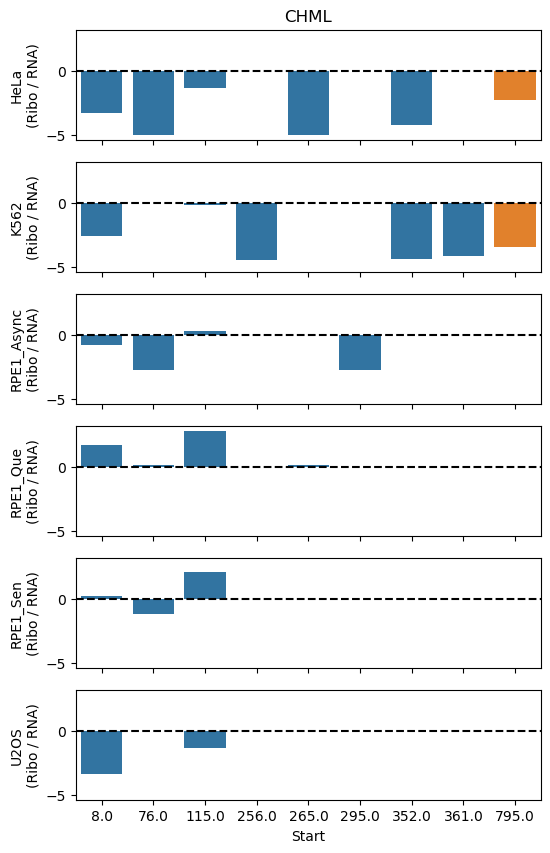

In [160]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000366553.3'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('CHML')

Text(0.5, 1.0, 'CD59')

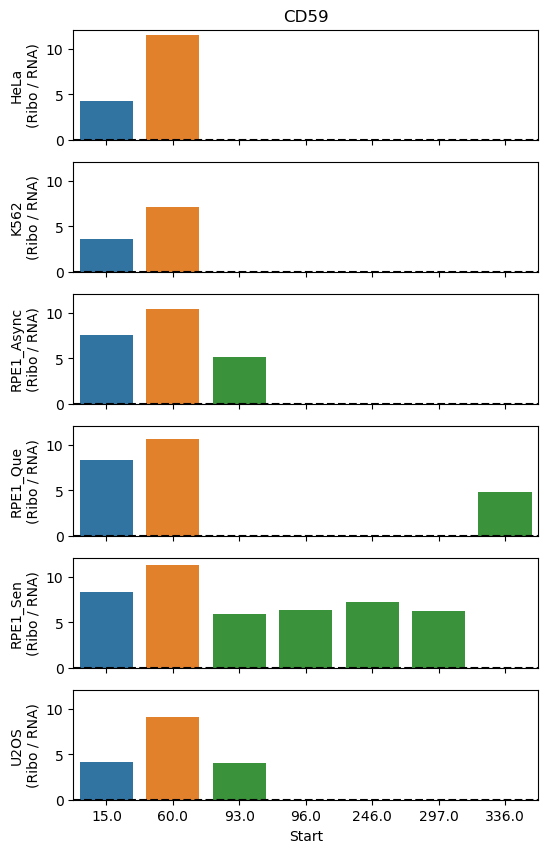

In [159]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000642928.2'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('CD59')